In [110]:
import os

# Print the directory structure to confirm the correct paths
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    for file in files:
        print("    ", file)


/kaggle/input
/kaggle/input/competitive-data-science-predict-future-sales
     items.csv
     sample_submission.csv
     item_categories.csv
     sales_train.csv
     shops.csv
     test.csv


In [111]:
# Import necessary libraries for data processing and visualization
import pandas as pd  # data processing, CSV file I/O
import numpy as np  # numerical operations
import matplotlib.pyplot as plt  # basic plotting
import seaborn as sns  # statistical data visualization

# Set a clean plot style
plt.style.use('ggplot')

# Load the datasets provided in the Kaggle competition
items = pd.read_csv('/kaggle/input/competitive-data-science-predict-future-sales/items.csv')
item_categories = pd.read_csv('/kaggle/input/competitive-data-science-predict-future-sales/item_categories.csv')
shops = pd.read_csv('/kaggle/input/competitive-data-science-predict-future-sales/shops.csv')
sales_train = pd.read_csv('/kaggle/input/competitive-data-science-predict-future-sales/sales_train.csv')
test = pd.read_csv('/kaggle/input/competitive-data-science-predict-future-sales/test.csv')
sample_submission = pd.read_csv('/kaggle/input/competitive-data-science-predict-future-sales/sample_submission.csv')

# Print the shape and first few rows of each dataframe to check the data
print("Items Shape:", items.shape)
print(items.head())
print("\nItem Categories Shape:", item_categories.shape)
print(item_categories.head())
print("\nShops Shape:", shops.shape)
print(shops.head())
print("\nSales Train Shape:", sales_train.shape)
print(sales_train.head())
print("\nTest Shape:", test.shape)
print(test.head())


Items Shape: (22170, 3)
                                           item_name  item_id  \
0          ! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.)         D        0   
1  !ABBYY FineReader 12 Professional Edition Full...        1   
2      ***В ЛУЧАХ СЛАВЫ   (UNV)                    D        2   
3    ***ГОЛУБАЯ ВОЛНА  (Univ)                      D        3   
4        ***КОРОБКА (СТЕКЛО)                       D        4   

   item_category_id  
0                40  
1                76  
2                40  
3                40  
4                40  

Item Categories Shape: (84, 2)
        item_category_name  item_category_id
0  PC - Гарнитуры/Наушники                 0
1         Аксессуары - PS2                 1
2         Аксессуары - PS3                 2
3         Аксессуары - PS4                 3
4         Аксессуары - PSP                 4

Shops Shape: (60, 2)
                        shop_name  shop_id
0   !Якутск Орджоникидзе, 56 фран        0
1   !Якутск ТЦ "Центральный" фран        1


In [112]:
# Check for missing values in each dataframe
print("\nMissing Values in Items:")
print(items.isna().sum())

print("\nMissing Values in Item Categories:")
print(item_categories.isna().sum())

print("\nMissing Values in Shops:")
print(shops.isna().sum())

print("\nMissing Values in Sales Train:")
print(sales_train.isna().sum())

print("\nMissing Values in Test:")
print(test.isna().sum())

# Display basic statistical summaries
print("\nSales Train Description:")
print(sales_train.describe())



Missing Values in Items:
item_name           0
item_id             0
item_category_id    0
dtype: int64

Missing Values in Item Categories:
item_category_name    0
item_category_id      0
dtype: int64

Missing Values in Shops:
shop_name    0
shop_id      0
dtype: int64

Missing Values in Sales Train:
date              0
date_block_num    0
shop_id           0
item_id           0
item_price        0
item_cnt_day      0
dtype: int64

Missing Values in Test:
ID         0
shop_id    0
item_id    0
dtype: int64

Sales Train Description:
       date_block_num    shop_id    item_id  item_price  item_cnt_day
count      2935849.00 2935849.00 2935849.00  2935849.00    2935849.00
mean            14.57      33.00   10197.23      890.85          1.24
std              9.42      16.23    6324.30     1729.80          2.62
min              0.00       0.00       0.00       -1.00        -22.00
25%              7.00      22.00    4476.00      249.00          1.00
50%             14.00      31.00    9343.

In [113]:
# Remove rows with negative prices or unrealistic high prices
# Only keep prices within a reasonable range (0 to 100,000)
sales_train = sales_train[(sales_train['item_price'] > 0) & (sales_train['item_price'] < 100000)]

# Remove rows with negative item counts or extremely high counts
# Only keep sales count within a reasonable range (0 to 1000)
sales_train = sales_train[(sales_train['item_cnt_day'] >= 0) & (sales_train['item_cnt_day'] < 1000)]

# Print the description again to verify the changes
print("\nSales Train Description After Cleaning:")
print(sales_train.describe())



Sales Train Description After Cleaning:
       date_block_num    shop_id    item_id  item_price  item_cnt_day
count      2928489.00 2928489.00 2928489.00  2928489.00    2928489.00
mean            14.57      33.00   10200.28      889.36          1.25
std              9.42      16.23    6324.40     1718.15          2.22
min              0.00       0.00       0.00        0.07          1.00
25%              7.00      22.00    4477.00      249.00          1.00
50%             14.00      31.00    9355.00      399.00          1.00
75%             23.00      47.00   15691.00      999.00          1.00
max             33.00      59.00   22169.00    59200.00        669.00


In [114]:
# Convert the 'date' column to datetime format for easier processing
sales_train['date'] = pd.to_datetime(sales_train['date'], format='%d.%m.%Y')

# Print a sample to check the conversion
print("\nSample Sales Data After Date Conversion:")
print(sales_train.head())



Sample Sales Data After Date Conversion:
        date  date_block_num  shop_id  item_id  item_price  item_cnt_day
0 2013-01-02               0       59    22154      999.00          1.00
1 2013-01-03               0       25     2552      899.00          1.00
3 2013-01-06               0       25     2554     1709.05          1.00
4 2013-01-15               0       25     2555     1099.00          1.00
5 2013-01-10               0       25     2564      349.00          1.00


In [115]:
# Aggregate data to monthly level
monthly_sales = sales_train.groupby(['date_block_num', 'shop_id', 'item_id']).agg({
    'item_cnt_day': 'sum',  # total sales for each item in each shop
    'item_price': 'mean'  # average price for each item in each shop
}).reset_index()

# Rename columns for clarity
monthly_sales.rename(columns={'item_cnt_day': 'item_cnt_month', 'item_price': 'avg_item_price'}, inplace=True)

# Print the first few rows to check the result
print("\nMonthly Sales Aggregation:")
print(monthly_sales.head())



Monthly Sales Aggregation:
   date_block_num  shop_id  item_id  item_cnt_month  avg_item_price
0               0        0       32            6.00          221.00
1               0        0       33            3.00          347.00
2               0        0       35            1.00          247.00
3               0        0       43            1.00          221.00
4               0        0       51            2.00          128.50


In [116]:
# Merge item category information
monthly_sales = pd.merge(monthly_sales, items[['item_id', 'item_category_id']], on='item_id', how='left')

# Merge shop information (optional, if shop clustering is needed later)
monthly_sales = pd.merge(monthly_sales, shops[['shop_id', 'shop_name']], on='shop_id', how='left')

# Print the first few rows to confirm the merge
print("\nMonthly Sales with Item and Shop Information:")
print(monthly_sales.head())



Monthly Sales with Item and Shop Information:
   date_block_num  shop_id  item_id  item_cnt_month  avg_item_price  \
0               0        0       32            6.00          221.00   
1               0        0       33            3.00          347.00   
2               0        0       35            1.00          247.00   
3               0        0       43            1.00          221.00   
4               0        0       51            2.00          128.50   

   item_category_id                      shop_name  
0                40  !Якутск Орджоникидзе, 56 фран  
1                37  !Якутск Орджоникидзе, 56 фран  
2                40  !Якутск Орджоникидзе, 56 фран  
3                40  !Якутск Орджоникидзе, 56 фран  
4                57  !Якутск Орджоникидзе, 56 фран  


In [117]:
# Add lag features for item counts
def add_lag_features(df, lags, col_name):
    for lag in lags:
        # Create a new column for each lag
        lag_col_name = f"{col_name}_lag_{lag}"
        temp_df = df[['date_block_num', 'shop_id', 'item_id', col_name]].copy()
        temp_df['date_block_num'] += lag  # shift the date block
        temp_df.rename(columns={col_name: lag_col_name}, inplace=True)
        # Merge the lag feature back to the main dataframe
        df = pd.merge(df, temp_df, on=['date_block_num', 'shop_id', 'item_id'], how='left')
    return df

# Add 1, 3, 6 month lags for item counts
monthly_sales = add_lag_features(monthly_sales, [1, 3, 6], 'item_cnt_month')


# Fill NaN values with 0 for lag features
monthly_sales.fillna(0, inplace=True)

# Print a sample to verify
print("\nMonthly Sales After Filling NaNs:")
print(monthly_sales.head())



Monthly Sales After Filling NaNs:
   date_block_num  shop_id  item_id  item_cnt_month  avg_item_price  \
0               0        0       32            6.00          221.00   
1               0        0       33            3.00          347.00   
2               0        0       35            1.00          247.00   
3               0        0       43            1.00          221.00   
4               0        0       51            2.00          128.50   

   item_category_id                      shop_name  item_cnt_month_lag_1  \
0                40  !Якутск Орджоникидзе, 56 фран                  0.00   
1                37  !Якутск Орджоникидзе, 56 фран                  0.00   
2                40  !Якутск Орджоникидзе, 56 фран                  0.00   
3                40  !Якутск Орджоникидзе, 56 фран                  0.00   
4                57  !Якутск Орджоникидзе, 56 фран                  0.00   

   item_cnt_month_lag_3  item_cnt_month_lag_6  
0                  0.00          

In [120]:
# Define a function to add rolling mean features
def add_rolling_mean_features(df, window_sizes, col_name):
    for window in window_sizes:
        rolling_col_name = f'{col_name}_rolling_{window}'
        
        # Create a temporary DataFrame to calculate rolling averages
        temp_df = df[['date_block_num', 'shop_id', 'item_id', col_name]].copy()
        
        # Calculate rolling mean per (shop_id, item_id) pair
        temp_df[rolling_col_name] = temp_df.groupby(['shop_id', 'item_id'])[col_name].transform(
            lambda x: x.shift(1).rolling(window=window).mean()
        )

        # Merge the result back into the main DataFrame without suffixes
        df = df.merge(temp_df[['date_block_num', 'shop_id', 'item_id', rolling_col_name]],
                      on=['date_block_num', 'shop_id', 'item_id'], how='left')

    return df


In [121]:
# Add rolling features for 3-month and 6-month windows
monthly_sales = add_rolling_mean_features(monthly_sales, [3, 6], 'item_cnt_month')

# Fill any NaNs resulting from rolling calculation
monthly_sales.fillna(0, inplace=True)

# Quick check of feature stats
print("\nRolling Feature Summary:")
print(monthly_sales[['item_cnt_month_rolling_3', 'item_cnt_month_rolling_6']].describe())



Rolling Feature Summary:
       item_cnt_month_rolling_3  item_cnt_month_rolling_6
count                1608224.00                1608224.00
mean                       1.25                      0.76
std                        6.70                      6.03
min                        0.00                      0.00
25%                        0.00                      0.00
50%                        0.00                      0.00
75%                        1.33                      0.00
max                     1090.67                   1010.33


In [122]:
# Identify rows with extremely high rolling counts for 3 and 6 months
# These might be data entry errors or rare outliers
outliers_3 = monthly_sales[monthly_sales['item_cnt_month_rolling_3_x'] > 1000]
outliers_6 = monthly_sales[monthly_sales['item_cnt_month_rolling_6_x'] > 1000]

# Print outliers for inspection
print("\nOutliers in Rolling 3 Month Counts:")
print(outliers_3[['date_block_num', 'shop_id', 'item_id', 'item_cnt_month_rolling_3_x']])

print("\nOutliers in Rolling 6 Month Counts:")
print(outliers_6[['date_block_num', 'shop_id', 'item_id', 'item_cnt_month_rolling_6_x']])

# Clip the rolling features to keep values within a reasonable range (0 to 1000)
monthly_sales['item_cnt_month_rolling_3_x'] = monthly_sales['item_cnt_month_rolling_3_x'].clip(0, 1000)
monthly_sales['item_cnt_month_rolling_6_x'] = monthly_sales['item_cnt_month_rolling_6_x'].clip(0, 1000)

# Check statistics again after clipping
print("\nAfter Clipping:")
print(monthly_sales[['item_cnt_month_rolling_3_x', 'item_cnt_month_rolling_6_x']].describe())



Outliers in Rolling 3 Month Counts:
        date_block_num  shop_id  item_id  item_cnt_month_rolling_3_x
716325              12       31    20949                     1090.67
766998              13       31    20949                     1064.33
814351              14       31    20949                     1048.33

Outliers in Rolling 6 Month Counts:
        date_block_num  shop_id  item_id  item_cnt_month_rolling_6_x
814351              14       31    20949                     1010.33

After Clipping:
       item_cnt_month_rolling_3_x  item_cnt_month_rolling_6_x
count                  1608224.00                  1608224.00
mean                         1.25                        0.76
std                          6.68                        6.03
min                          0.00                        0.00
25%                          0.00                        0.00
50%                          0.00                        0.00
75%                          1.33                        0.00

In [123]:
# Add time-based features to capture seasonality and long-term trends

# Extract year and month from the date_block_num (each block is a month)
monthly_sales['year'] = monthly_sales['date_block_num'] // 12 + 2013  # First block is Jan 2013
monthly_sales['month'] = monthly_sales['date_block_num'] % 12

# Calculate days in month for potential use as a seasonal feature
import calendar
monthly_sales['days_in_month'] = monthly_sales['month'].apply(lambda x: calendar.monthrange(2013, x+1)[1])

# Add a quarter indicator to capture quarterly effects
monthly_sales['quarter'] = monthly_sales['month'] // 3 + 1

# Preview the updated dataframe
print("\nMonthly Sales with Time-based Features:")
print(monthly_sales[['date_block_num', 'year', 'month', 'days_in_month', 'quarter']].head())



Monthly Sales with Time-based Features:
   date_block_num  year  month  days_in_month  quarter
0               0  2013      0             31        1
1               0  2013      0             31        1
2               0  2013      0             31        1
3               0  2013      0             31        1
4               0  2013      0             31        1


In [124]:
# Add item category level features to capture broader trends

# Calculate total sales for each item category per month
category_monthly_sales = monthly_sales.groupby(['date_block_num', 'item_category_id']).agg({
    'item_cnt_month': 'sum',
    'avg_item_price': 'mean'
}).reset_index()

# Rename columns for clarity
category_monthly_sales.rename(columns={
    'item_cnt_month': 'category_cnt_month',
    'avg_item_price': 'category_avg_price'
}, inplace=True)

# Merge category features back to the main dataframe
monthly_sales = pd.merge(
    monthly_sales,
    category_monthly_sales,
    on=['date_block_num', 'item_category_id'],
    how='left'
)

# Print a sample to confirm the merge
print("\nMonthly Sales with Category Features:")
print(monthly_sales[['date_block_num', 'item_category_id', 'category_cnt_month', 'category_avg_price']].head())



Monthly Sales with Category Features:
   date_block_num  item_category_id  category_cnt_month  category_avg_price
0               0                40            33532.00              213.88
1               0                37             6132.00              456.94
2               0                40            33532.00              213.88
3               0                40            33532.00              213.88
4               0                57             1542.00              277.71


In [125]:
# Add trend features to capture long-term changes

# Calculate overall sales trend by item
item_trend = monthly_sales.groupby(['item_id']).agg({
    'item_cnt_month': 'mean'
}).reset_index()

# Rename for clarity
item_trend.rename(columns={'item_cnt_month': 'item_avg_monthly_sales'}, inplace=True)

# Merge back to the main dataframe
monthly_sales = pd.merge(
    monthly_sales,
    item_trend,
    on='item_id',
    how='left'
)

# Calculate overall sales trend by shop
shop_trend = monthly_sales.groupby(['shop_id']).agg({
    'item_cnt_month': 'mean'
}).reset_index()

# Rename for clarity
shop_trend.rename(columns={'item_cnt_month': 'shop_avg_monthly_sales'}, inplace=True)

# Merge back to the main dataframe
monthly_sales = pd.merge(
    monthly_sales,
    shop_trend,
    on='shop_id',
    how='left'
)

# Print a sample to verify the merge
print("\nMonthly Sales with Trend Features:")
print(monthly_sales[['item_id', 'item_avg_monthly_sales', 'shop_id', 'shop_avg_monthly_sales']].head())



Monthly Sales with Trend Features:
   item_id  item_avg_monthly_sales  shop_id  shop_avg_monthly_sales
0       32                    2.67        0                    2.43
1       33                    1.49        0                    2.43
2       35                    2.96        0                    2.43
3       43                    1.00        0                    2.43
4       51                    1.40        0                    2.43


In [126]:
# Encode shop names as numerical labels
monthly_sales['shop_name_encoded'] = monthly_sales['shop_name'].astype('category').cat.codes

# Encode item category IDs as numerical labels (already in numeric format, but ensure consistency)
monthly_sales['item_category_id_encoded'] = monthly_sales['item_category_id'].astype('category').cat.codes

# Print a sample to verify the encoding
print("\nMonthly Sales with Encoded Features:")
print(monthly_sales[['shop_name', 'shop_name_encoded', 'item_category_id', 'item_category_id_encoded']].head())



Monthly Sales with Encoded Features:
                       shop_name  shop_name_encoded  item_category_id  \
0  !Якутск Орджоникидзе, 56 фран                  0                40   
1  !Якутск Орджоникидзе, 56 фран                  0                37   
2  !Якутск Орджоникидзе, 56 фран                  0                40   
3  !Якутск Орджоникидзе, 56 фран                  0                40   
4  !Якутск Орджоникидзе, 56 фран                  0                57   

   item_category_id_encoded  
0                        40  
1                        37  
2                        40  
3                        40  
4                        57  


In [127]:
# Drop columns that are no longer needed for training
columns_to_drop = ['shop_name', 'item_category_id']
monthly_sales.drop(columns=columns_to_drop, inplace=True)

# Print the final structure to verify
print("\nFinal Monthly Sales Data Sample:")
print(monthly_sales.head())



Final Monthly Sales Data Sample:
   date_block_num  shop_id  item_id  item_cnt_month  avg_item_price  \
0               0        0       32            6.00          221.00   
1               0        0       33            3.00          347.00   
2               0        0       35            1.00          247.00   
3               0        0       43            1.00          221.00   
4               0        0       51            2.00          128.50   

   item_cnt_month_lag_1  item_cnt_month_lag_3  item_cnt_month_lag_6  \
0                  0.00                  0.00                  0.00   
1                  0.00                  0.00                  0.00   
2                  0.00                  0.00                  0.00   
3                  0.00                  0.00                  0.00   
4                  0.00                  0.00                  0.00   

   item_cnt_month_rolling_3_x  item_cnt_month_rolling_6_x  ...  year  month  \
0                        0.00    

In [128]:
# Separate features (X) and target (y)
X = monthly_sales.drop(columns=['item_cnt_month'])
y = monthly_sales['item_cnt_month']

# Print the shapes to confirm
print("\nFeature Matrix (X) and Target (y) Shapes:")
print("X:", X.shape)
print("y:", y.shape)

# Print a sample of X and y
print("\nFeature Matrix Sample (X):")
print(X.head())

print("\nTarget Variable Sample (y):")
print(y.head())



Feature Matrix (X) and Target (y) Shapes:
X: (1608224, 23)
y: (1608224,)

Feature Matrix Sample (X):
   date_block_num  shop_id  item_id  avg_item_price  item_cnt_month_lag_1  \
0               0        0       32          221.00                  0.00   
1               0        0       33          347.00                  0.00   
2               0        0       35          247.00                  0.00   
3               0        0       43          221.00                  0.00   
4               0        0       51          128.50                  0.00   

   item_cnt_month_lag_3  item_cnt_month_lag_6  item_cnt_month_rolling_3_x  \
0                  0.00                  0.00                        0.00   
1                  0.00                  0.00                        0.00   
2                  0.00                  0.00                        0.00   
3                  0.00                  0.00                        0.00   
4                  0.00                  0.00     

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes to confirm the split
print("\nTraining Set Shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\nValidation Set Shapes:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

# Standardize the features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Print a sample to confirm scaling
import pandas as pd
print("\nScaled Training Set Sample:")
print(pd.DataFrame(X_train_scaled).head())



Training Set Shapes:
X_train: (1286579, 23)
y_train: (1286579,)

Validation Set Shapes:
X_val: (321645, 23)
y_val: (321645,)

Scaled Training Set Sample:
     0     1     2     3     4     5     6     7     8     9   ...    13  \
0 -1.01  1.28  0.01 -0.35 -0.06 -0.02 -0.13 -0.04 -0.13 -0.04  ... -1.02   
1 -1.54 -1.56  0.01 -0.32 -0.18 -0.16 -0.13 -0.19 -0.13 -0.19  ... -1.02   
2  1.19 -0.23 -0.86 -0.32 -0.18  0.25 -0.13 -0.19 -0.13 -0.19  ...  1.55   
3 -1.33  0.13  1.37 -0.42 -0.18 -0.16 -0.13 -0.19 -0.13 -0.19  ... -1.02   
4 -0.59  1.04  0.51 -0.39 -0.06  0.12  0.02  0.01  0.07  0.01  ... -1.02   

     14    15    16    17    18    19    20    21    22  
0 -0.05 -0.47 -0.35  0.49 -0.38 -0.25  0.65  1.28  0.83  
1 -1.49  0.65 -1.24  2.78 -0.41 -0.21 -0.38 -1.56 -0.09  
2 -0.91  0.65 -1.24 -0.05 -0.35  0.48 -0.23 -0.23  0.83  
3 -0.91  0.65 -1.24  3.10 -0.41 -0.23 -0.44  0.13 -0.09  
4  1.11  0.65  1.44  0.29 -0.37 -0.22 -0.28  1.04  0.83  

[5 rows x 23 columns]


In [130]:
!pip install statsmodels matplotlib


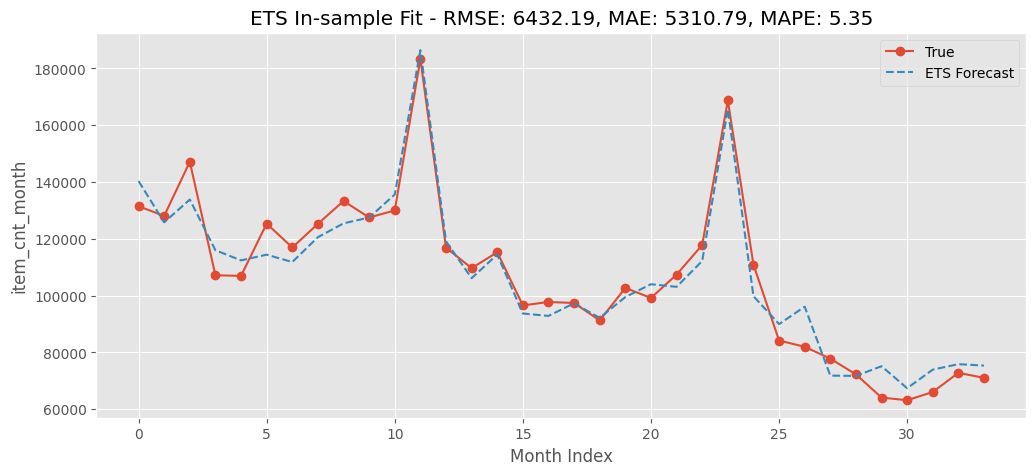

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Step 1: Aggregate raw sales to monthly level
monthly_sales = sales.groupby('date_block_num').agg({'item_cnt_day': 'sum'}).reset_index()
monthly_sales.rename(columns={'item_cnt_day': 'item_cnt_month'}, inplace=True)

# Step 2: Prepare the target time series
y_series = monthly_sales['item_cnt_month'].astype(float)
y_scaled = y_series / 1000  # Optional scaling to aid convergence

# Step 3: Fit ETS model
ets_model = ExponentialSmoothing(y_scaled, trend='add', seasonal='add', seasonal_periods=12)
ets_fit = ets_model.fit()

# Step 4: Forecast future values (same length for consistency)
ets_forecast_scaled = ets_fit.fittedvalues  # in-sample prediction
ets_forecast = ets_forecast_scaled * 1000   # scale back

# Step 5: Evaluate on in-sample prediction
ets_rmse = mean_squared_error(y_series, ets_forecast, squared=False)
ets_mae = mean_absolute_error(y_series, ets_forecast)

# Avoid divide-by-zero for MAPE
mask = y_series != 0
ets_mape = np.mean(np.abs((y_series[mask] - ets_forecast[mask]) / y_series[mask])) * 100

# Step 6: Visualize
plt.figure(figsize=(12, 5))
plt.plot(y_series.values, label='True', marker='o')
plt.plot(ets_forecast, label='ETS Forecast', linestyle='--')
plt.title(f"ETS In-sample Fit - RMSE: {ets_rmse:.2f}, MAE: {ets_mae:.2f}, MAPE: {ets_mape:.2f}")
plt.xlabel("Month Index")
plt.ylabel("item_cnt_month")
plt.legend()
plt.grid(True)
plt.show()


In [183]:
sales['date'] = pd.to_datetime(sales['date'], format='%d.%m.%Y')
monthly_sales = sales.groupby(['date_block_num', 'date']).agg({'item_cnt_day': 'sum'}).reset_index()
monthly_sales.rename(columns={'item_cnt_day': 'item_cnt_month'}, inplace=True)

monthly_sales = monthly_sales.sort_values('date')  # 排序很重要
monthly_sales['year'] = monthly_sales['date'].dt.year
monthly_sales['month'] = monthly_sales['date'].dt.month
monthly_sales['quarter'] = monthly_sales['date'].dt.quarter
monthly_sales['day_of_year'] = monthly_sales['date'].dt.dayofyear
monthly_sales['day_of_month'] = monthly_sales['date'].dt.day
monthly_sales['week_of_year'] = monthly_sales['date'].dt.isocalendar().week


In [184]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Custom MAPE function to avoid division by zero
def safe_mape(y_true, y_pred):
    epsilon = 1e-8
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), epsilon)))

# --- Ensure datetime column and extract features ---
# Convert 'date' column to datetime format
monthly_sales['date'] = pd.to_datetime(monthly_sales['date'], format='%d.%m.%Y', errors='coerce')

# Drop any rows where 'date' could not be parsed
monthly_sales = monthly_sales.dropna(subset=['date'])

# Sort data chronologically just in case
monthly_sales = monthly_sales.sort_values('date')

# Extract time-based features
monthly_sales['year'] = monthly_sales['date'].dt.year
monthly_sales['month'] = monthly_sales['date'].dt.month
monthly_sales['quarter'] = monthly_sales['date'].dt.quarter
monthly_sales['day_of_year'] = monthly_sales['date'].dt.dayofyear
monthly_sales['day_of_month'] = monthly_sales['date'].dt.day
monthly_sales['week_of_year'] = monthly_sales['date'].dt.isocalendar().week

# Select features and target column
feature_cols = [
    'date_block_num', 'year', 'month', 'quarter',
    'day_of_year', 'day_of_month', 'week_of_year'
]
target_col = 'item_cnt_month'

# Define training data
X = monthly_sales[feature_cols]
y = monthly_sales[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize CatBoost model
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function='RMSE',
    random_seed=42,
    verbose=0  # Suppress output
)

# Train the model
cat_model.fit(X_train, y_train)

# Make predictions
cat_predictions = cat_model.predict(X_test)

# Evaluate the model
cat_rmse = mean_squared_error(y_test, cat_predictions, squared=False)
cat_mae = mean_absolute_error(y_test, cat_predictions)
cat_mape = safe_mape(y_test, cat_predictions)

# Display results
print(f"CatBoost Model - RMSE: {cat_rmse:.4f}, MAE: {cat_mae:.4f}, MAPE: {cat_mape:.4f}")


CatBoost Model - RMSE: 1095.3747, MAE: 777.1245, MAPE: 0.2069


In [191]:
# Function to add rolling average features
def add_rolling_mean_features(df, window_sizes, col_name='item_cnt_month'):
    for window in window_sizes:
        new_col = f'{col_name}_rolling_{window}'
        df[new_col] = df.groupby('item_id')[col_name].transform(
            lambda x: x.shift(1).rolling(window=window).mean()
        )
    return df

# Apply to monthly_sales
monthly_sales = add_rolling_mean_features(monthly_sales, [3, 6], col_name='item_cnt_month')
monthly_sales = monthly_sales.dropna()


In [192]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# Define input features for the MLP model
feature_cols = [
    'date_block_num', 'year', 'month', 'quarter',
    'day_of_year', 'day_of_month', 'week_of_year',
    'item_cnt_month_rolling_3', 'item_cnt_month_rolling_6'
]
target_col = 'item_cnt_month'

# Extract features and target from the full dataset
X = monthly_sales[feature_cols]
y = monthly_sales[target_col]

# Standardize the feature values (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use a smaller sample for faster testing
X_small, _, y_small, _ = train_test_split(X_scaled, y, train_size=5000, random_state=42)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_small, y_small, test_size=0.2, random_state=42)

# Initialize and train the MLP model
mlp_model = MLPRegressor(hidden_layer_sizes=(64,), max_iter=200, random_state=42)
mlp_model.fit(X_train, y_train)

# Make predictions
y_pred = mlp_model.predict(X_test)

# Flatten predictions and targets
y_test_flat = np.ravel(y_test)
y_pred_flat = np.ravel(y_pred)

# Evaluate the model
mlp_rmse = mean_squared_error(y_test_flat, y_pred_flat, squared=False)
mlp_mae = mean_absolute_error(y_test_flat, y_pred_flat)

# Avoid divide-by-zero in MAPE calculation
mask = y_test_flat != 0
mlp_mape = mean_absolute_percentage_error(y_test_flat[mask], y_pred_flat[mask])

# Print evaluation results
print(f"Simplified MLP Model - RMSE: {mlp_rmse:.4f}, MAE: {mlp_mae:.4f}, MAPE: {mlp_mape:.4f}")




Simplified MLP Model - RMSE: 8.3138, MAE: 1.3666, MAPE: 0.6151


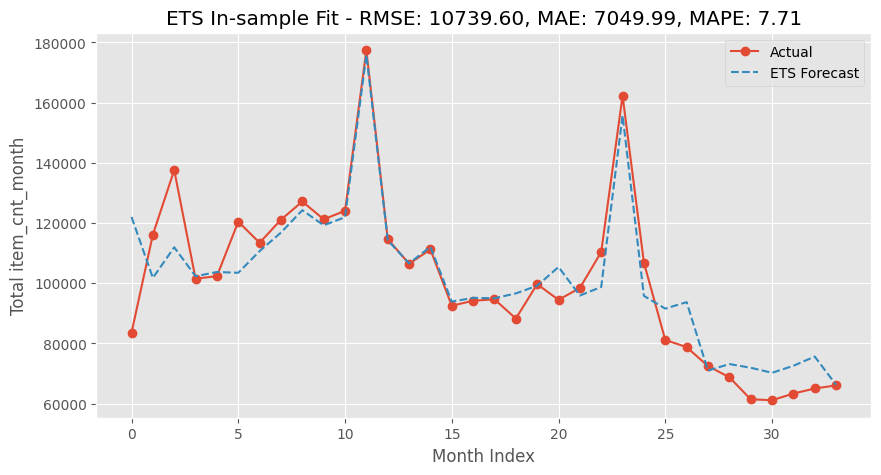

In [195]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error

monthly_sales['date'] = pd.to_datetime(monthly_sales['date'], format='%d.%m.%Y', errors='coerce')
monthly_sales = monthly_sales.dropna(subset=['date'])
monthly_sales = monthly_sales.sort_values('date')

# Aggregate total monthly sales 
monthly_total = monthly_sales.groupby('date_block_num')['item_cnt_month'].sum().reset_index()

# Train ETS model on monthly total sales
y_ets = monthly_total['item_cnt_month']
ets_model = ExponentialSmoothing(y_ets, trend='add', seasonal='add', seasonal_periods=12).fit()
ets_pred = ets_model.fittedvalues

# Compute ETS evaluation metrics
ets_rmse = mean_squared_error(y_ets, ets_pred, squared=False)
ets_mae = mean_absolute_error(y_ets, ets_pred)
mask = y_ets != 0
ets_mape = np.mean(np.abs((y_ets[mask] - ets_pred[mask]) / y_ets[mask])) * 100

# Plot actual vs ETS forecast
plt.figure(figsize=(10, 5))
plt.plot(y_ets.values, label='Actual', marker='o')
plt.plot(ets_pred.values, label='ETS Forecast', linestyle='--')
plt.title(f'ETS In-sample Fit - RMSE: {ets_rmse:.2f}, MAE: {ets_mae:.2f}, MAPE: {ets_mape:.2f}')
plt.xlabel('Month Index')
plt.ylabel('Total item_cnt_month')
plt.legend()
plt.grid(True)
plt.show()



CatBoost - RMSE: 7.9854, MAE: 1.7736, MAPE: 94.8635
MLP      - RMSE: 7.9862, MAE: 1.7817, MAPE: 95.6146


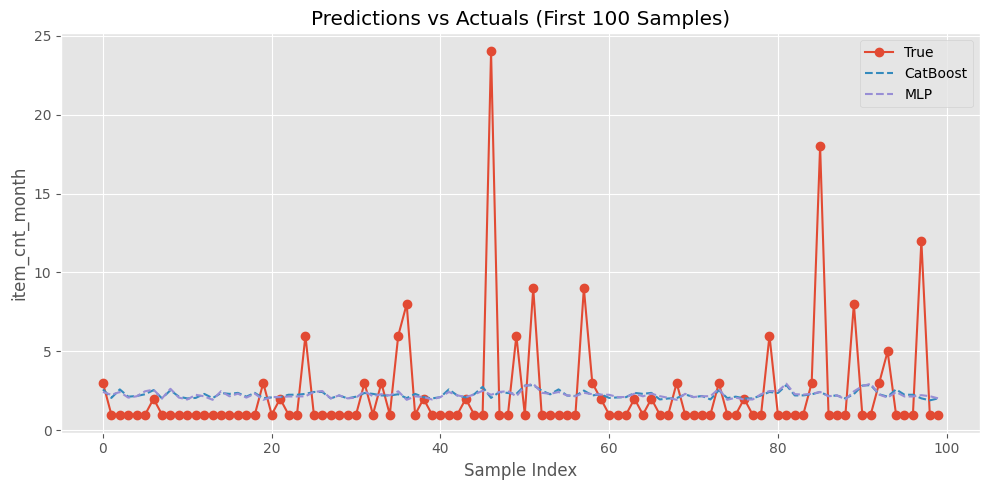

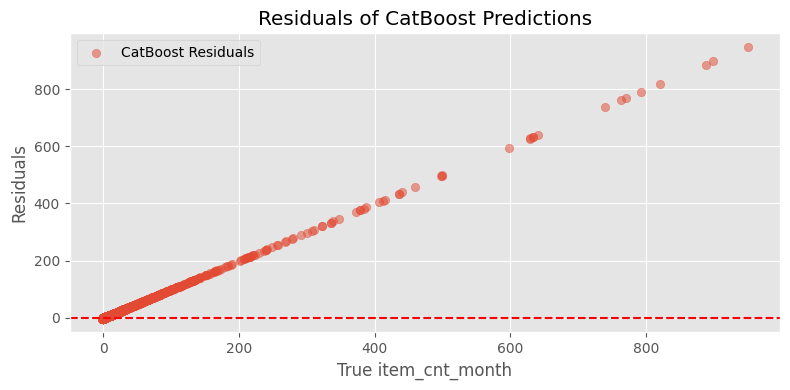

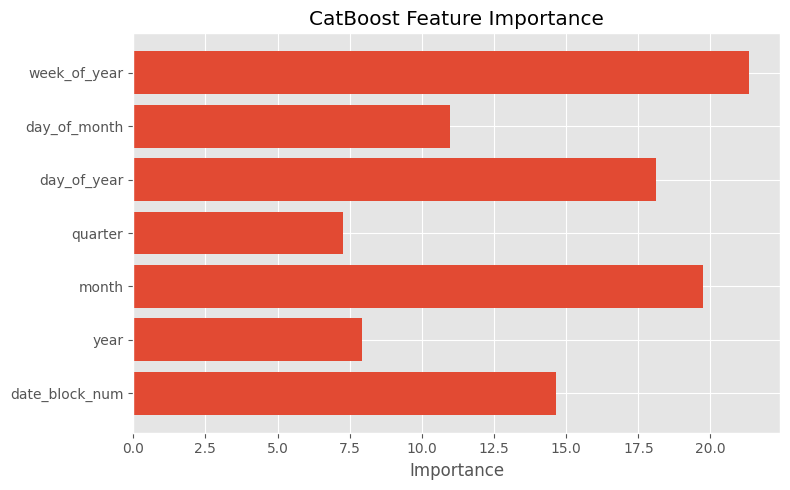

In [200]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Custom MAPE function
def safe_mape(y_true, y_pred):
    epsilon = 1e-8
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / np.maximum(np.abs(y_true[mask]), epsilon))) * 100

# Flatten arrays for metrics
y_test_flat = np.ravel(y_test)
cat_pred_flat = np.ravel(cat_pred)
mlp_pred_flat = np.ravel(mlp_pred)

# --- Evaluation for CatBoost ---
cat_rmse = mean_squared_error(y_test_flat, cat_pred_flat, squared=False)
cat_mae = mean_absolute_error(y_test_flat, cat_pred_flat)
cat_mape = safe_mape(y_test_flat, cat_pred_flat)

# --- Evaluation for MLP ---
mlp_rmse = mean_squared_error(y_test_flat, mlp_pred_flat, squared=False)
mlp_mae = mean_absolute_error(y_test_flat, mlp_pred_flat)
mlp_mape = safe_mape(y_test_flat, mlp_pred_flat)

# --- Print metrics ---
print(f"CatBoost - RMSE: {cat_rmse:.4f}, MAE: {cat_mae:.4f}, MAPE: {cat_mape:.4f}")
print(f"MLP      - RMSE: {mlp_rmse:.4f}, MAE: {mlp_mae:.4f}, MAPE: {mlp_mape:.4f}")

# --- Visualization: Predictions vs Actual ---
plt.figure(figsize=(10, 5))
plt.plot(y_test_flat[:100], label="True", marker='o')
plt.plot(cat_pred_flat[:100], label="CatBoost", linestyle='--')
plt.plot(mlp_pred_flat[:100], label="MLP", linestyle='--')
plt.title("Predictions vs Actuals (First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("item_cnt_month")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Residual Plot (CatBoost) ---
cat_residuals = y_test_flat - cat_pred_flat
plt.figure(figsize=(8, 4))
plt.scatter(y_test_flat, cat_residuals, alpha=0.5, label="CatBoost Residuals")
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("True item_cnt_month")
plt.ylabel("Residuals")
plt.title("Residuals of CatBoost Predictions")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Feature Importance (CatBoost only) ---
importances = cat_model.get_feature_importance()
feature_names = monthly_sales[feature_cols].columns

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances)
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.grid(True)
plt.tight_layout()
plt.show()


In [202]:
import pandas as pd
import numpy as np

test_df = pd.read_csv('/kaggle/input/competitive-data-science-predict-future-sales/test.csv')


test_df['date_block_num'] = 34
test_df['year'] = 2015
test_df['month'] = 11
test_df['quarter'] = 4
test_df['day_of_year'] = 305
test_df['day_of_month'] = 30
test_df['week_of_year'] = 48


feature_cols = [
    'date_block_num', 'year', 'month', 'quarter',
    'day_of_year', 'day_of_month', 'week_of_year'
]
X_final = test_df[feature_cols]

preds = cat_model.predict(X_final)

preds = np.clip(preds, 0, 20)

submission = pd.DataFrame({
    'ID': test_df['ID'],
    'item_cnt_month': preds
})

submission.to_csv('/kaggle/working/submission.csv', index=False)
print("submission.csv saved to /kaggle/working/")


submission.csv saved to /kaggle/working/
